Data Splitting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data=fetch_california_housing()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target, name="MedHouseValue")

df=X.copy()
df['target']=y
display(df)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Analisi esplorativa

hist di pandas, ritorna una figura con istogrammi con distribuzioni di tutte le feature. suddivide i campioni in gruppi di 30 con bins

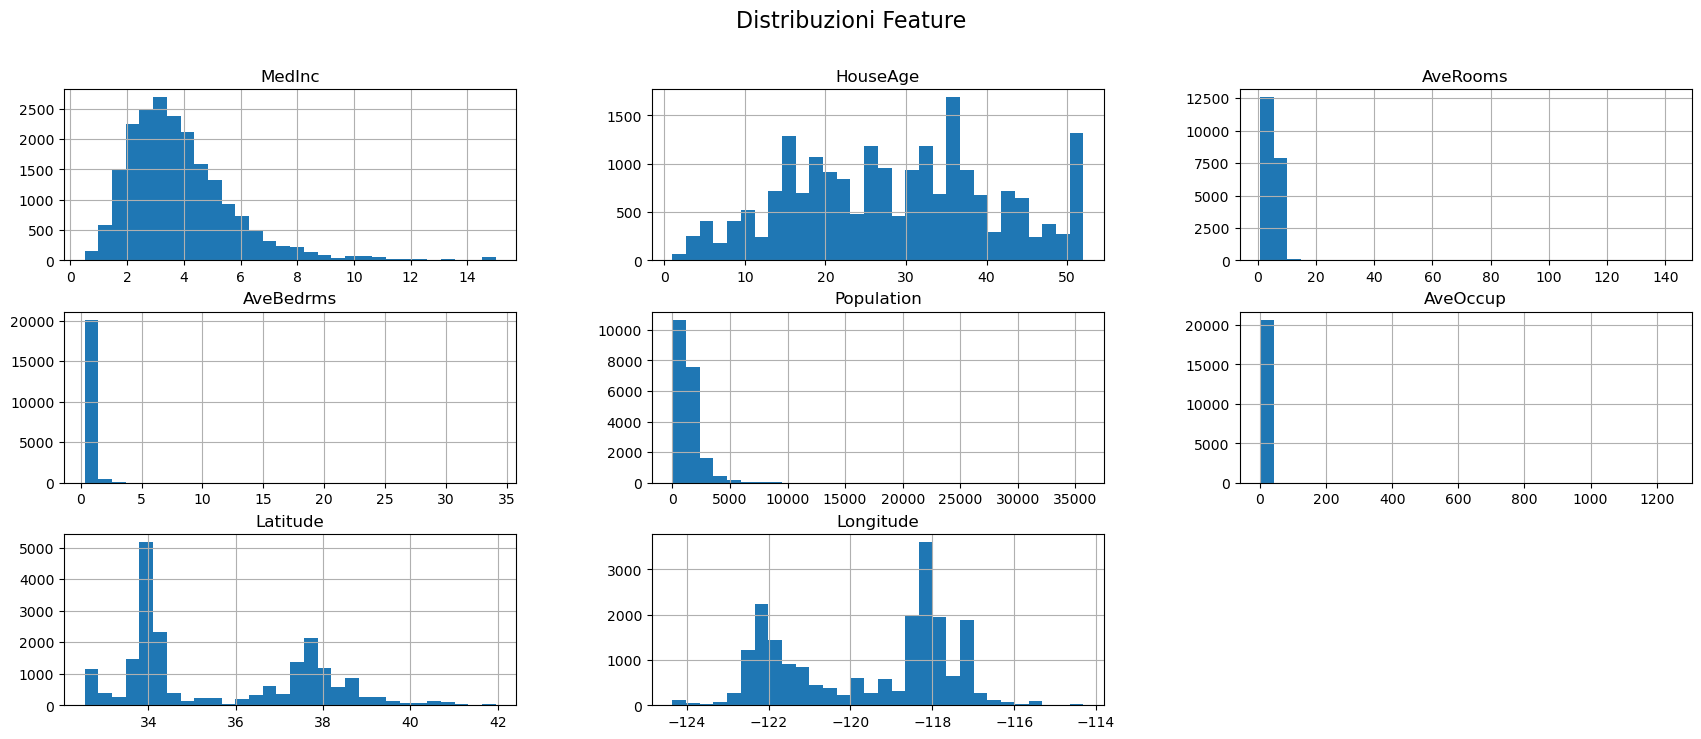

In [6]:
X.hist(bins=30,figsize=(21,8))
plt.suptitle("Distribuzioni Feature",fontsize=16)
plt.show()

istogramma del target

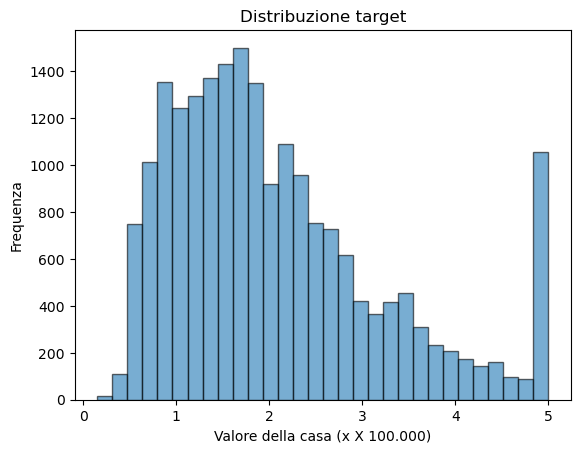

In [7]:
plt.hist(y,bins=30,edgecolor='black',alpha=0.6)
plt.title("Distribuzione target")
plt.xlabel("Valore della casa (x X 100.000)")
plt.ylabel("Frequenza")
plt.show()

Standarizzazione/normalizzazione
lo scaling deve essere eseguito dopo aver suddiviso i dati in set di training e test.
Questo per evitare il fenomeno del datalake, ossia che il set di test venga influenzato dal set di training.
Questo processo avviene perchè i dati di test vengono calcolati anche tenendono conto delle informazioni statistsiche del training set, per cui il modello vedrebbe anche dei dati che dovrebbero essere visti solo nella fase di valutazione (test). Per cui partiamo con il datasplitting

In [8]:
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
print(f"Training set:\t{X_train.shape}")
print(f"Test set:\t{X_test.shape}")

Training set:	(16512, 8)
Test set:	(4128, 8)


ora applichiamao lo scaler

In [10]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

ora facciamo il training del modello con regressione lineare

In [13]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred_traing=model.predict(X_train_scaled)
y_pred_test=model.predict(X_test_scaled)

mse_train=mean_squared_error(y_train,y_pred_traing)
mse_test=mean_squared_error(y_test,y_pred_test)
r2_train=r2_score(y_train,y_pred_traing)
r2_test=r2_score(y_test,y_pred_test)

print(f"MES train:\t{mse_train}\t MES test: {mse_test}")
print(f"R2 train:\t{r2_train}\t R2 test: {r2_test}")

MES train:	0.5179331255246699	 MES test: 0.5388649914036732
R2 train:	0.6125511913966952	 R2 test: 0.5887810596909611


MES su train rappresenta l'errore medio che il modello commette sui dati cha ha imparato
MSE su test è l'errore medio che il modello commette sui dati mai visti prima (errore di generalizzazione)
Un modello si adatta sempre leggermente meglio sui dati che ha già visto
R2 dice quanta varianza è catturata dal modello, 0.6125 sui dasti di test vuol dire che cattura il 60% quindi il 40% della varianza non è catturata dal modello, questo potrebbe anche essere dovuto al fatto che i dati potrebbero non avere una natura lineare, mentre ho scelto un modello lineare.
La differenza tra train e test è del 3% in genere molto piccola, il modelle generalizza bene.
Forge la regressione lineare non è sufficiente in questo caso, per catturare le relazioni tra le variabili (se non è una relazione lineare) e quindi applicare modelli non lineari, o applicare il feature enginering